<a href="https://colab.research.google.com/github/Raksh1707/Naturalproject/blob/main/nlp5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import nltk
import string
from collections import Counter

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.sentiment import SentimentIntensityAnalyzer

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('vader_lexicon')



[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [20]:
df = pd.DataFrame({
    "Comment": [
    "I absolutely love this product. Great quality and excellent performance.",
    "The delivery was fast and the packaging was perfect.",
    "Very disappointed with the product quality.",
    "Amazing experience! I will definitely buy again.",
    "The customer service was very helpful and friendly.",
    "The product arrived damaged and late.",
    "Excellent value for money. Highly recommended.",
    "The battery life is outstanding and lasts all day.",
    "I expected better quality for this price.",
    "The new update made the app much faster.",
    "Poor customer support. No response to my complaint.",
    "The design is modern and very attractive.",
    "Shipping was delayed, but the product is good.",
    "This is the best purchase I have made this year.",
    "The product stopped working after a few days.",
    "I am very happy with my purchase.",
    "The camera quality is amazing.",
    "Not satisfied with the overall performance.",
    "Easy to use and install. Great experience.",
    "Waste of money. I would not recommend it.",
    "The product exceeded my expectations.",
    "Packaging could have been much better.",
    "The app crashes frequently after the latest update.",
    "Fast shipping and excellent customer service.",
    "The screen quality is bright and crystal clear.",
    "I regret buying this product.",
    "Very reliable and easy to operate.",
    "The price is a bit high, but the quality is excellent.",
    "Customer support solved my issue quickly.",
    "The product looks premium and stylish.",
    "Battery drains much faster than expected.",
    "Fantastic performance and smooth operation.",
    "I love the new features introduced in the latest version.",
    "The product is average and nothing special.",
    "Excellent build quality and durable materials.",
    "Completely disappointed with the purchase.",
    "The sound quality is impressive.",
    "Very comfortable and user-friendly.",
    "The delivery took longer than expected.",
    "Highly recommended for anyone looking for quality.",
    "The product is exactly as described.",
    "Terrible experience with customer care.",
    "Good quality for the price.",
    "The latest marketing campaign was very creative."
    ]
})
df.head()


,Comment
0,I absolutely love this product. Great quality ...
1,The delivery was fast and the packaging was pe...
2,Very disappointed with the product quality.
3,Amazing experience! I will definitely buy again.
4,The customer service was very helpful and frie...


In [21]:
stop_words = set(stopwords.words("english"))

def clean_text(text):
    text = text.lower()

    # Remove punctuation
    text = text.translate(str.maketrans("", "", string.punctuation))

    words = text.split()

    # Remove stopwords
    words = [word for word in words if word not in stop_words]

    return " ".join(words)

df["Clean_Comment"] = df["Comment"].apply(clean_text)

print("\nCleaned Comments")
print(df[["Comment", "Clean_Comment"]].head())


Cleaned Comments
                                             Comment  \
0  I absolutely love this product. Great quality ...   
1  The delivery was fast and the packaging was pe...   
2        Very disappointed with the product quality.   
3   Amazing experience! I will definitely buy again.   
4  The customer service was very helpful and frie...   

                                       Clean_Comment  
0  absolutely love product great quality excellen...  
1                    delivery fast packaging perfect  
2                       disappointed product quality  
3                  amazing experience definitely buy  
4                  customer service helpful friendly  


In [22]:
sia = SentimentIntensityAnalyzer()

def sentiment(text):
    score = sia.polarity_scores(text)["compound"]

    if score >= 0.05:
        return "Positive"
    elif score <= -0.05:
        return "Negative"
    else:
        return "Neutral"

df["Sentiment"] = df["Comment"].apply(sentiment)

print("\nSentiment Analysis")
print(df[["Comment", "Sentiment"]])


Sentiment Analysis
                                              Comment Sentiment
0   I absolutely love this product. Great quality ...  Positive
1   The delivery was fast and the packaging was pe...  Positive
2         Very disappointed with the product quality.  Negative
3    Amazing experience! I will definitely buy again.  Positive
4   The customer service was very helpful and frie...  Positive
5               The product arrived damaged and late.  Negative
6      Excellent value for money. Highly recommended.  Positive
7   The battery life is outstanding and lasts all ...  Positive
8           I expected better quality for this price.  Positive
9            The new update made the app much faster.   Neutral
10  Poor customer support. No response to my compl...  Negative
11          The design is modern and very attractive.  Positive
12     Shipping was delayed, but the product is good.  Positive
13   This is the best purchase I have made this year.  Positive
14      The product 

In [23]:
all_words = " ".join(df["Clean_Comment"])

word_list = all_words.split()

word_frequency = Counter(word_list)

top_words = word_frequency.most_common(10)

print("\nTop 10 Trending Words")
for word, count in top_words:
    print(word, ":", count)



Top 10 Trending Words
product : 10
quality : 10
excellent : 5
customer : 5
performance : 3
experience : 3
expected : 3
price : 3
much : 3
purchase : 3


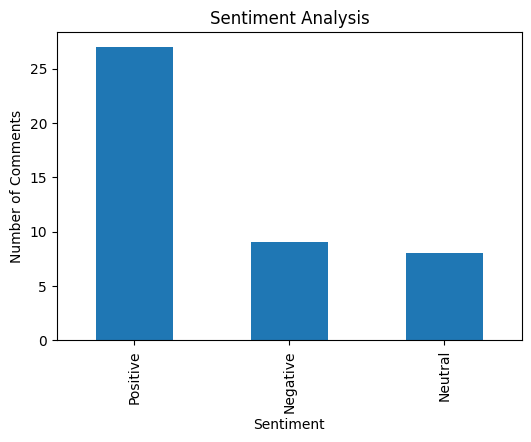

In [24]:
plt.figure(figsize=(6,4))
df["Sentiment"].value_counts().plot(kind="bar")
plt.title("Sentiment Analysis")
plt.xlabel("Sentiment")
plt.ylabel("Number of Comments")
plt.show()

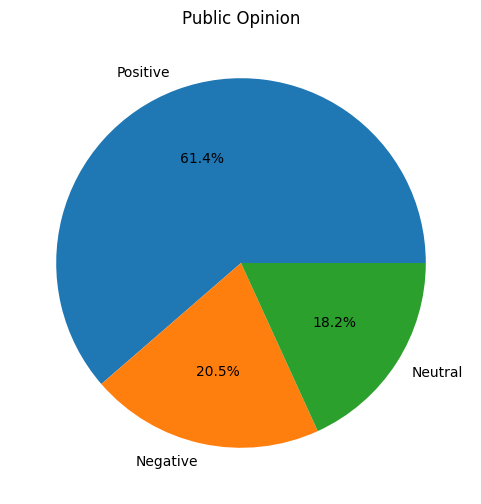

In [25]:
plt.figure(figsize=(6,6))
df["Sentiment"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)
plt.ylabel("")
plt.title("Public Opinion")
plt.show()

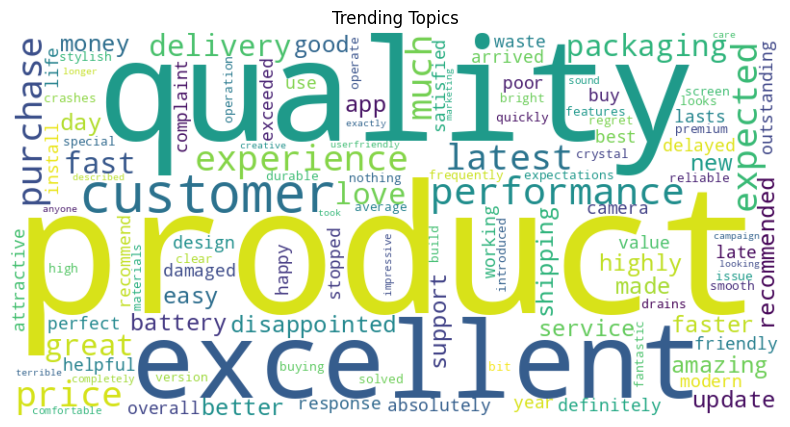

In [26]:
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(all_words)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Trending Topics")
plt.show()

In [27]:
df.to_csv("Social_Media_Analysis_Output.csv", index=False)

print("\nAnalysis Completed Successfully!")
print("Output saved as Social_Media_Analysis_Output.csv")


Analysis Completed Successfully!
Output saved as Social_Media_Analysis_Output.csv
